In [3]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())

Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


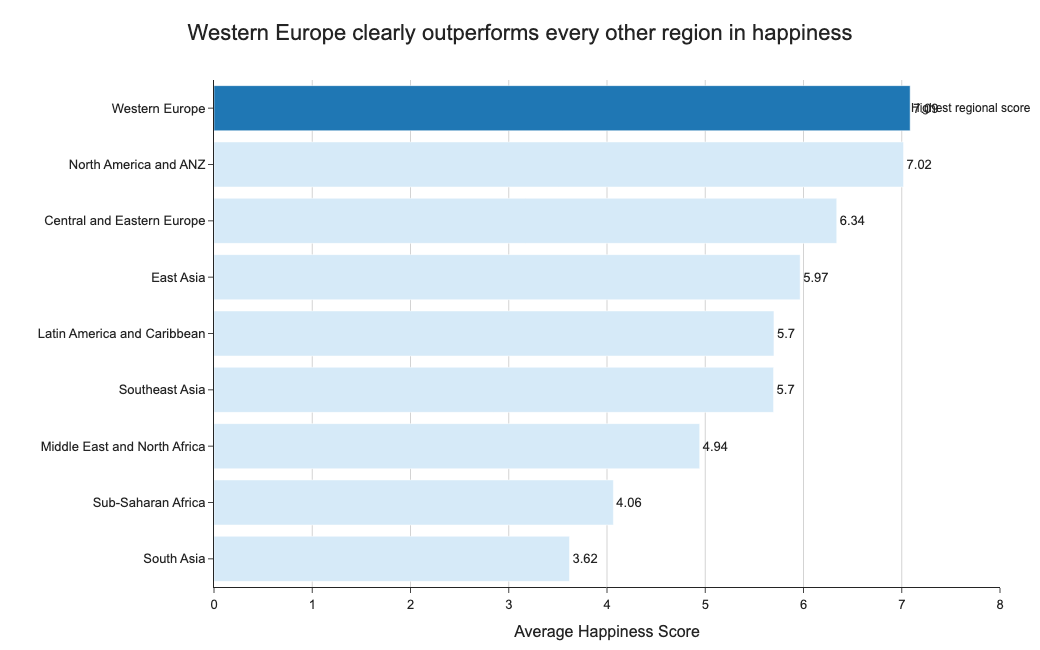

In [7]:
# Task 1: Regional comparison bar chart
import plotly.express as px
import plotly.graph_objects as go

# Step 1: Compute average happiness score by region
region_avg = (
    df.groupby('Region')['Happiness_Score']
      .mean()
      .reset_index()
      .sort_values('Happiness_Score', ascending=True)
)

# Step 2: Create colours
colors = ['#D6EAF8'] * len(region_avg)
colors[-1] = '#1F77B4'   # highlight happiest region

# Step 3: Build chart
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=region_avg['Happiness_Score'],
        y=region_avg['Region'],
        orientation='h',
        marker_color=colors,
        text=region_avg['Happiness_Score'].round(2),
        textposition='outside'
    )
)

# Step 4: Styling
fig.update_layout(
    title={
        'text': 'Western Europe clearly outperforms every other region in happiness',
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis_title='Average Happiness Score',
    yaxis_title='',
    template='simple_white',
    height=650,
    width=1000,
    font=dict(
        family='Arial',
        size=13
    ),
    title_font=dict(
        size=22
    ),
    margin=dict(l=20, r=40, t=80, b=40)
)

fig.update_xaxes(
    range=[0, 8],
    showgrid=True,
    gridcolor='lightgray'
)

fig.update_yaxes(showgrid=False)

top_region = region_avg.iloc[-1]

fig.add_annotation(
    x=top_region['Happiness_Score'],
    y=top_region['Region'],
    text='Highest regional score',
    showarrow=True,
    arrowhead=2,
    ax=60,
    ay=0,
    font=dict(size=12)
)

fig.show()

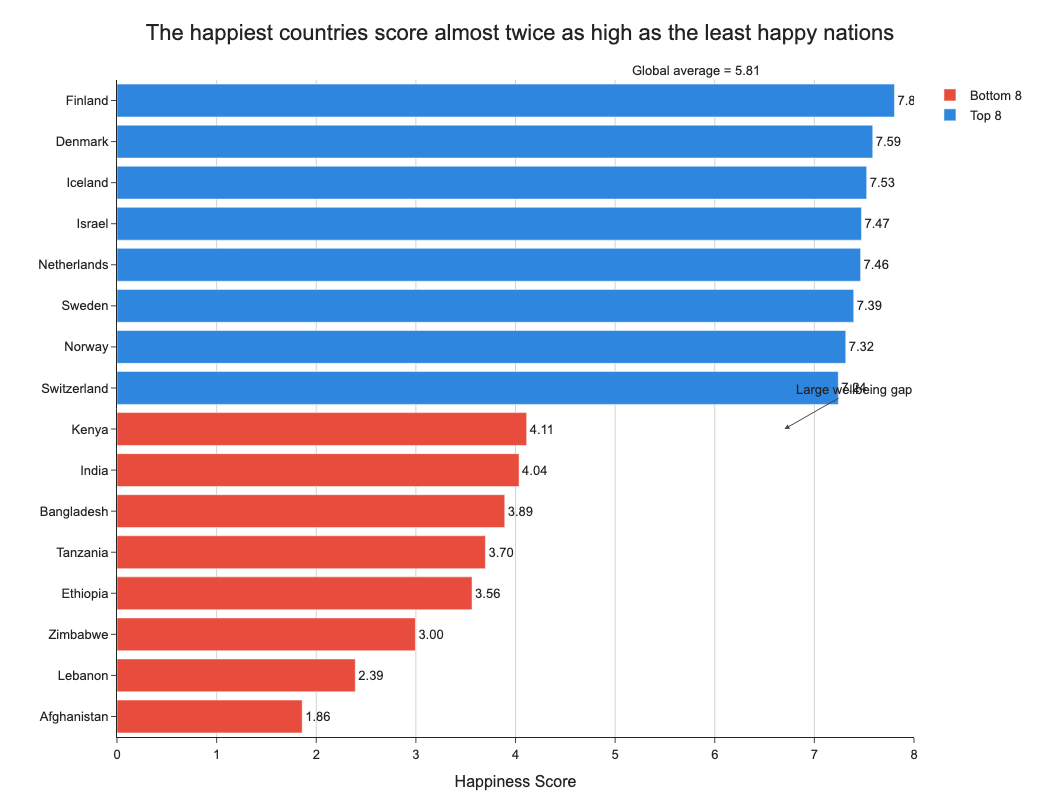

In [8]:
# Task 2: Top 8 vs Bottom 8 contrast

import plotly.express as px
import plotly.graph_objects as go

# Step 1: Prepare data
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'

bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8])
combined = combined.sort_values('Happiness_Score')

global_avg = df['Happiness_Score'].mean()

# Step 2: Custom colours
color_map = {
    'Top 8': '#2E86DE',
    'Bottom 8': '#E74C3C'
}

# Step 3: Build chart
fig = px.bar(
    combined,
    x='Happiness_Score',
    y='Country',
    orientation='h',
    color='Group',
    text='Happiness_Score',
    color_discrete_map=color_map
)

# Step 4: Clean styling
fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

fig.update_layout(
    title={
        'text': 'The happiest countries score almost twice as high as the least happy nations',
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis_title='Happiness Score',
    yaxis_title='',
    template='simple_white',
    height=800,
    width=1100,
    font=dict(
        family='Arial',
        size=13
    ),
    title_font=dict(
        size=22
    ),
    legend_title='',
    margin=dict(l=20, r=40, t=80, b=40)
)

# Zero baseline rule
fig.update_xaxes(
    range=[0, 8],
    showgrid=True,
    gridcolor='lightgray'
)

fig.update_yaxes(showgrid=False)

# Global average reference line
fig.add_vline(
    x=global_avg,
    line_dash='dash',
    line_color='black',
    annotation_text=f'Global average = {global_avg:.2f}',
    annotation_position='top'
)

# Gap annotation
fig.add_annotation(
    x=6.7,
    y=7,
    text='Large wellbeing gap',
    showarrow=True,
    arrowhead=2,
    ax=70,
    ay=-40
)

fig.show()